In [1]:
import pandas as pd

### Load the train dataset

In [2]:
x_train = pd.read_csv("../Dataset/train_feature.csv")
y_train = pd.read_csv("../Dataset/train_target.csv")

In [3]:
x_train.head(2)

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,resp_min,resp_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope
0,0.913389,0.005173,0.8776,0.9638,-0.016038,0.010455,-0.0658,0.0358,0.043496,0.028134,...,-16.688538,16.481018,0.91506,0.004632,0.883394,0.989889,4.066667,0.200000,-8.423019e-07,1.554092e-06
1,0.775276,0.022214,0.6970,0.9678,-0.184002,0.052689,-0.3142,-0.0678,-0.507589,0.042673,...,-8.822632,7.829285,0.94734,0.013927,0.794010,1.059903,3.966667,0.166667,-2.676707e-06,-7.402926e-08


In [4]:
y_train.head(2)

,label
0,0
1,0


### Model training
as xgboost needs the test dataset therefor we need to do one more train test split

In [5]:
from sklearn.model_selection import train_test_split

df = pd.concat([x_train, y_train], axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [17]:
train.shape, test.shape

((1480, 41), (370, 41))

In [6]:
x = train.drop("label", axis=1)
y = train["label"]

y_test = test["label"]
x_test = test.drop("label", axis=1)

In [7]:
from xgboost import XGBClassifier, plot_importance, plot_tree

model = XGBClassifier(
    n_estimators      = 100,       # number of boosting rounds
    max_depth         = 3,         # depth of each tree
    learning_rate     = 0.2,       # shrinks contribution of each tree (eta)
    subsample         = 0.7,       # fraction of samples per tree
    colsample_bytree  = 0.7,       # fraction of features per tree
    gamma             = 0,         # min loss reduction to split a node
    reg_alpha         = 0,         # L1 regularization
    reg_lambda        = 1,         # L2 regularization
    eval_metric       = "logloss",  # "logloss" for binary
    objective        = "binary:logistic",  # ← add this for binary (0/1)
    random_state      = 42,
    n_jobs            = -1
)



model.fit(
    x, y,
    eval_set              = [(x, y), (x_test, y_test)],
    verbose               = 10        # print every 10 rounds
)

[0]	validation_0-logloss:0.56628	validation_1-logloss:0.57163
[10]	validation_0-logloss:0.16666	validation_1-logloss:0.19848
[20]	validation_0-logloss:0.08122	validation_1-logloss:0.11026
[30]	validation_0-logloss:0.04253	validation_1-logloss:0.07557
[40]	validation_0-logloss:0.02828	validation_1-logloss:0.06361
[50]	validation_0-logloss:0.01810	validation_1-logloss:0.05670
[60]	validation_0-logloss:0.01268	validation_1-logloss:0.04936
[70]	validation_0-logloss:0.00959	validation_1-logloss:0.04858
[80]	validation_0-logloss:0.00783	validation_1-logloss:0.04827
[90]	validation_0-logloss:0.00644	validation_1-logloss:0.04692
[99]	validation_0-logloss:0.00565	validation_1-logloss:0.04595


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### check the accuracy

In [8]:
y_pred = model.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9837837837837838
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       173
           1       0.98      0.99      0.98       197

    accuracy                           0.98       370
   macro avg       0.98      0.98      0.98       370
weighted avg       0.98      0.98      0.98       370



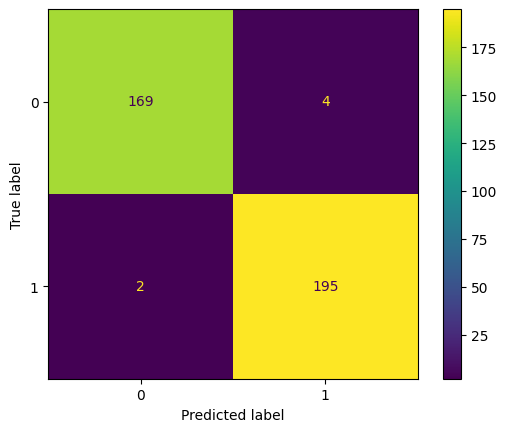

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

### Validate the model

In [ ]:
x_val = pd.read_csv("../Dataset/val_feature.csv")
y_val = pd.read_csv("../Dataset/val_target.csv")

In [13]:
y_pred = model.predict(x_val)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.9627118644067797
              precision    recall  f1-score   support

           0       1.00      0.96      0.97       223
           1       0.88      0.99      0.93        72

    accuracy                           0.96       295
   macro avg       0.94      0.97      0.95       295
weighted avg       0.97      0.96      0.96       295



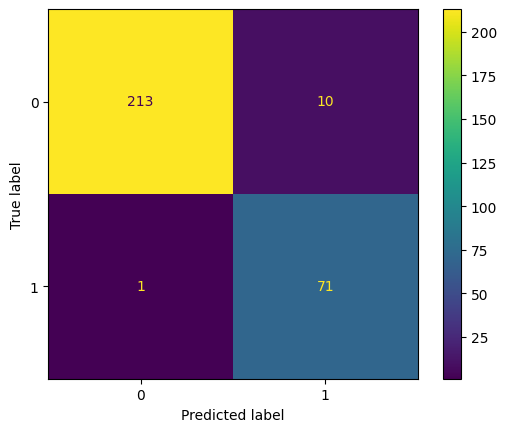

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
# cm = confusion_matrix(y_test_res, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

### save the model

In [18]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved")

Model saved
